In [1]:
import h5py
from functools import partial
from tqdm.notebook import tqdm
import numpy as np
from spikeparam.patch.fit import SpikeGroup

# SpikeGroup API

`SpikeGroup` is an sub-class of `Spike` and is used to compute spike features across non-continuous 2d signals.

## Reader
The `reader` arg of the `.fit()` method may be used to pass a function to the reads a series of 1d signal files into memory, and extracts the spikes per file into a 2d array, which is subsequently processed in parallel.

Alternatively, 2d signal arrays may be passed directly into `.fit()` if efficient memory usage is not required. Since either method is parallelized at the spike level, both are equivalent in terms of computation efficiency.


## Alt
The `.alt()` method is used to extract custom features from alternative signals (e.g. LFP, stimulus, etc). This method be be called after `.fit()`, or queued (`.alt(queue=True)`) to execute at the end of `.fit()`. Queing allows for interoperability with ndspflow, sklearn, etc, and is more efficient since less jobs are sent to the multiprocessing pool.

In [2]:
# Load data
fs = 200000 

def reader(ind, alt=False):
    
    file = h5py.File('pvc-6/151145.04_Data.h5', 'r')

    dset = dset = file['Sweep_' + str(ind)]
    
    if alt:
        sig = dset[:, 0]
    else:
        sig = dset[:, 1]
    
    return sig

def compute_alt_features(stim, fs):

    return stim.mean(), stim.std()

## 1. Queue (recommended)

In [3]:
# Queueing: interoperability with ndspflow, sklearn, etc
#
# Below, the .alt can be seen as an extension of the __init__
#   method and is executed at the end of the .fit() call.

sg_queue = SpikeGroup()


sg_queue.alt(np.arange(20), fs, compute_alt_features, reader=partial(reader, alt=True), queue=True,
             param_keys=['stim_mean', 'stim_std'], ref='inflection', window_length=(20, 0))


sg_queue.fit(np.arange(20), fs, reader=reader, n_jobs=-1, progress=tqdm)

  0%|          | 0/18 [00:00<?, ?it/s]

## 2. Sequential

In [4]:
# Sequential method calls
sg_seq = SpikeGroup()

sg_seq.fit(np.arange(20), fs, reader=reader, n_jobs=-1, progress=tqdm)

sg_seq.alt(np.arange(20), fs, compute_alt_features, reader=partial(reader, alt=True),
           param_keys=['stim_mean', 'stim_std'], ref='inflection', window_length=(20, 0), n_jobs=-1, progress=tqdm)

  0%|          | 0/18 [00:00<?, ?it/s]

  0%|          | 0/18 [00:00<?, ?it/s]

## Pre-loaded Arrays

In [5]:
# Pre-loading
#
# Below shows how to not use a reader, an instead directly pass
#   in arrays sig and stim arrays to the first arg of .alt and .fit.
#   This is a less memory efficient approach since now the entire
#   sig array is stored in memory.
sigs = []
stims = []

for i in range(20):
    sigs.append(reader(i))
    stims.append(reader(i, alt=True))

In [6]:
sg = SpikeGroup()

sg.alt(stims, fs, compute_alt_features, queue=True,
       param_keys=['stim_mean', 'stim_std'], ref='inflection', window_length=(20, 0))
    
sg.fit(sigs, fs, n_jobs=-1, progress=tqdm)

  0%|          | 0/18 [00:00<?, ?it/s]

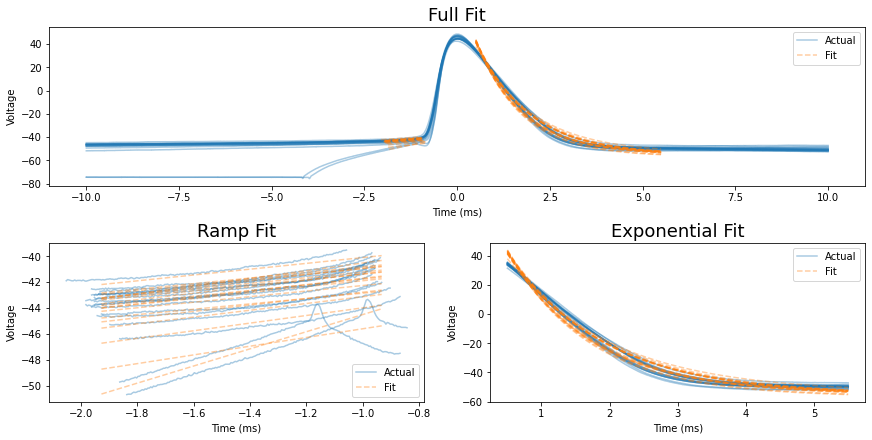

In [7]:
sg.plot_summary()